In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
dataset= pd.read_csv("Social_Network_Ads.csv")

In [4]:
print(dataset.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [5]:
x=dataset.iloc[:,[2,3]].values

In [6]:
y=dataset.iloc[:,4].values

In [11]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=0)

In [14]:
from sklearn.preprocessing import StandardScaler
sc_x=StandardScaler()
xtrain=sc_x.fit_transform(xtrain)
xtest=sc_x.transform(xtest)


In [17]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()
classifier.fit(xtrain,ytrain)

LogisticRegression()

In [19]:
y_pred=classifier.predict(xtest)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1])

In [20]:
train_pred=classifier.predict(xtrain)

In [22]:
result=pd.DataFrame({'Actual':ytest,'Predicted':y_pred})
result.head(15)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,1


In [23]:
result

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
95,1,0
96,0,0
97,1,0
98,1,1


In [24]:
from sklearn.metrics import precision_score,confusion_matrix,accuracy_score,recall_score
cm= confusion_matrix(ytest, y_pred)

In [25]:
cm

array([[65,  3],
       [ 8, 24]])

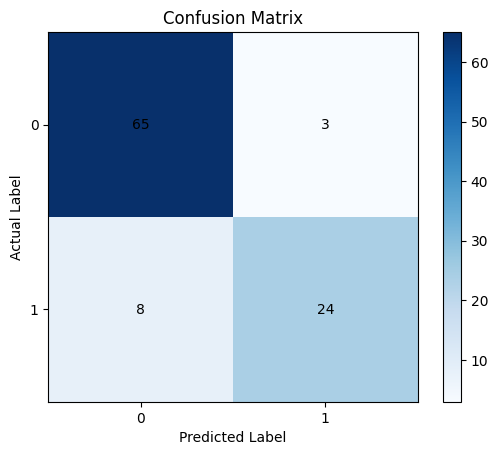

In [26]:
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1])
plt.yticks([0,1])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha="center",va="center",color="black")

plt.show()

In [27]:
cm = confusion_matrix(ytest, y_pred)

tn, fp, fn, tp = cm.ravel()

print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)
accuracy = (tp + tn) / (tp + tn + fp + fn)
print("Accuracy:", accuracy)
precision = tp / (tp + fp)
print("Precision:", precision)
recall = tp / (tp + fn)
print("Recall:", recall)
error_rate = (fp + fn) / (tp + tn + fp + fn)
print("Error Rate:", error_rate)

True Negative (TN): 65
False Positive (FP): 3
False Negative (FN): 8
True Positive (TP): 24
Accuracy: 0.89
Precision: 0.8888888888888888
Recall: 0.75
Error Rate: 0.11
